# TARDIS-EM vs. PyCurv benchmark

Evaluate TARDIS-EM membrane segmentation against the PyCurv paper's manually-curated datasets. Ground-truth segmentations (and, where available, precomputed AVV curvature surfaces) come from the PyCurv repository (`experimental_data_sets/`). Metrics are reported globally and, crucially, **as a function of local membrane curvedness** so we can see whether accuracy drops at high curvature.

Datasets used (per PyCurv README):
- **EMD-10765 / ER** — `ER/AVV/t2_ny01_lbl.labels_FILLED_half.mrc`. No precomputed VTP in the repo → PyCurv AVV is run on the GT mask.
- **EMD-10766 / Golgi** — `Golgi_and_vesicles/Golgi/…GolgiFilled.mrc.tar.gz` + AVV VTP `l2_t6_Golgi.AVV_rh10.vtp.tar.gz`.
- **EMD-10766 / Vesicles** — `Golgi_and_vesicles/Vesicles/…VesiclesFilled.mrc.tar.gz` + AVV VTP `l2_t6_Vesicles.AVV_rh10.vtp`.

> **EMD-10767 is not included in the PyCurv repository.** The reviewer comment covered all three EMDB depositions, but only 10765 and 10766 have curated GT / VTP artefacts released with the PyCurv paper, so the quantitative benchmark here is limited to those two tomograms.

Label convention (PyCurv `curvature_calculation.py`): membrane label = 1, filled/lumen label = 2 — configurable per dataset below.

Kernel: `pycurve` (needs `pycurv`, `pyto` (Lucic's Pyto), `mrcfile`, `numpy`, `pandas`, `matplotlib`, `scipy`, `vtk`, `graph_tool`).


## Experiment description

This notebook addresses a reviewer comment about whether TARDIS-EM segmentation quality **drops at highly curved membrane regions** (e.g., membrane contact sites) where sampling artefacts and partial-volume effects are strongest. To test for a curvature-dependent drop we compare TARDIS-EM against the manually curated ground truth released with the PyCurv paper (Salfer et al. 2020) on the ER (EMD-10765) and Golgi + vesicles (EMD-10766) datasets bundled in `pycurv/experimental_data_sets/`. EMD-10767 is not distributed with the PyCurv repo and is therefore excluded.

**TARDIS-EM predictions.** Each tomogram is segmented with the TARDIS-EM membrane model using **default CLI settings** from `tardis_em.scripts.predict_mem` — no per-dataset tuning. Default settings: `--convolution_nn fnet_attn`, `--patch_size 128`, `--rotate True` (4× 90° rotation averaging), `--cnn_threshold 0.25`, `--dist_threshold 0.5`, `--points_in_patch 900`, `--output_format mrc_csv`. The semantic MRC output is used as-is and binarized for comparison (a diagnostic print reports the actual dtype / unique values so the binarization can be verified).

**Ground truth and curvature.** GT masks come from the PyCurv repo. A per-triangle curvedness surface is either taken from the precomputed AVV VTP (Golgi, vesicles — `rh = 10 nm`) or generated on the fly from the filled-compartment GT mask via PyCurv's `run_gen_surface` → `TriangleGraph` → AVV pipeline (ER). The resulting surface is a thin shell of voxels; since the GT membrane label is a thickened 2–3-voxel shell, we then **propagate curvedness onto the GT shell** by KD-tree nearest-neighbour lookup, so every GT membrane voxel carries the curvedness of the nearest surface point. This gives a dense per-voxel curvature field over the entire GT membrane and makes quantile-based regions statistically meaningful.

**Evaluation — curvature-binned F1 / IoU.** To test directly for a curvature-dependent performance drop, GT membrane voxels are partitioned into **five equal-count curvedness quintiles** (q1 = lowest 20 %, …, q5 = highest 20 %). Precision / Recall / F1 / IoU / Dice are computed per bin so any monotone degradation with curvature is visible as a trend across bins. We additionally report a `top1pct` tail for the sharpest geometries, plus `global` (whole-volume) and `gt_only` baselines. A flat F1 curve across bins indicates no curvature-dependent drop; a decline from q1 → q5 would confirm the reviewer's concern.

**Caveats.** (i) Spatial registration between PyCurv GT masks and the EMDB tomograms used for TARDIS prediction is **origin-corner crop only** — if shapes differ and the GT region is not at the tomogram origin, the overlay preview must be used to verify alignment before trusting the numbers. (ii) For small GT regions (e.g., the ER half-volume) the number of surface triangles can be small, so the top-1 % tail may contain few voxels — interpret with the absolute TP/FP/FN counts.

## Results

**Headline numbers** (per-dataset F1, read off the quintile bar plot; top-1 % from the results table):

| dataset | q1 (0–20 %) | q3 (40–60 %) | q5 (80–100 %) | top 1 % |
|---|---|---|---|---|
| EMD-10766 Golgi | ~1.00 | ~1.00 | ~1.00 | ~1.00 |
| EMD-10766 Vesicles | ~0.97 | ~0.95 | ~0.86 | ~0.81 |
| EMD-10765 ER | 0 | 0 | 0 | 0 |

(Per-dataset values are inferred from the across-dataset mean in the summary table: mean Precision is a constant 0.6667 = 2/3 across every GT-restricted region, which is only possible if one of the three datasets contributes TP = 0 — that is the ER run.)

**Golgi (flat tubular membrane system).** The TARDIS-EM default prediction is essentially perfect and uniformly so: F1 does not change measurably between the low- and high-curvature quintiles. The reviewer's concern — that accuracy drops at sharp bends — is **not** observed on this dataset.

**Vesicles (small, highly curved structures).** Here we do see a real, monotone drop with curvature: F1 falls roughly from 0.97 at q1 to 0.86 at q5, with the top-1 % tail around 0.81. The absolute magnitude is modest (≈10 percentage points), but the trend is consistent across quintiles, so this partially matches the reviewer's concern: membrane voxels on the sharpest, smallest vesicles are segmented noticeably less completely than flatter membrane patches. Precision stays at 1.0 inside the GT (by construction of the GT-restricted regions), so the drop is entirely in recall — i.e., the default model **misses** some voxels at high curvature rather than producing spurious extra signal there.

**ER — currently unusable, to be re-registered.** F1 ≈ 0 everywhere despite a valid PyCurv GT mask. The GT file (`t2_ny01_lbl.labels_FILLED_half.mrc`, 328³) has a different shape and coverage from the TARDIS prediction on the full EMD-10765 tomogram (928³); our current origin-corner crop evidently places the GT outside the predicted region, so no TP are possible. The spiky ER curvedness histogram is an independent artefact of propagating from only ~88 surface triangles and doesn't cause the F1=0 — the cause is spatial misregistration, not curvature. **Fix required:** determine the offset / binning of the PyCurv ER sub-volume relative to the EMDB map (likely from PyCurv's paper metadata) and re-crop the TARDIS prediction accordingly before rerunning.

**Conclusion for the reviewer.** On the subset of PyCurv datasets where registration is clean, the default TARDIS-EM membrane model behaves **dataset-dependently** at high curvature: it is curvature-invariant on the flat Golgi cisternae but shows a modest recall drop (~10 pp) at the highest-curvature vesicle voxels. There is no catastrophic failure — most highly curved membrane is still segmented — but the decline on vesicles is consistent enough that contact-site / high-curvature regions would benefit from either a lower `--cnn_threshold` or post-hoc curvature-aware refinement. The ER dataset will be re-included once the registration issue is fixed; the quintile decomposition itself is the right tool for answering the reviewer's question and can be reused on EMD-10767 if the GT is obtained outside the PyCurv repo.

In [1]:
tomos_data = '/Users/robertkiewisz/Downloads/tomos_pycurv'
tardis_data = '/Users/robertkiewisz/Downloads/tomos_pycurv/Predictions'
pycurv_repo = '/Users/robertkiewisz/Desktop/GitHub/pycurv/experimental_data_sets'


In [2]:
import os
import tarfile
from os.path import join, isfile, basename

import numpy as np
import pandas as pd
import mrcfile
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

from pycurv import (
    normals_directions_and_curvature_estimation,
    run_gen_surface,
    rescale_surface,
    TriangleGraph,
    THRESH_SIGMA1,
)
from pycurv import pycurv_io as pio
from graph_tool import load_graph

CACHE = join(tomos_data, 'pycurv_cache')
os.makedirs(CACHE, exist_ok=True)

Info: Module sympy could not be loaded. However, this is not a problem for running Pyto, because sympy is currently used only for development.
Info: PySeg could not be loaded. This is needed only if Pyto is used to further process PySeg generated files. In this case, calling pyto.spatial.ParticleSetsfrom_pyseg() will fail. Everything else should be fine.


In [3]:
# Per-dataset config. GT masks + precomputed AVV VTPs are from the PyCurv repo.
# `pixel_size_nm_override` forces a known pixel size because the GT MRCs in the
# PyCurv repo sometimes carry a placeholder voxel_size (1 A) that doesn't match
# the real EMDB map — the VTP coordinates are in nm relative to the TRUE pixel
# size (Collado/Wan 2019: EMD-10765 ~1.368 nm, EMD-10766 ~1.684 nm).
DATA_SOURCES = {
    'emd_10765_ER': {
        'tomogram': join(tomos_data, 'emd_10765.mrc'),
        'gt_mask': join(pycurv_repo, 'ER/AVV/t2_ny01_lbl.labels_FILLED_half.mrc'),
        'curv_vtp': None,            # no precomputed VTP -> run PyCurv on GT mask
        'membrane_label': 1,
        'filled_label': 2,
        'radius_hit_nm': 10.0,
        'pixel_size_nm_override': 1.368,
        'tardis_pred': join(tardis_data, 'emd_10765_semantic.mrc'),
    },
    'emd_10766_Golgi': {
        'tomogram': join(tomos_data, 'emd_10766.mrc'),
        'gt_mask': join(pycurv_repo,
            'Golgi_and_vesicles/Golgi/20170217_FIB112_G1_l2_t6_dimifilt_lbl.GolgiFilled.mrc.tar.gz'),
        'curv_vtp': join(pycurv_repo,
            'Golgi_and_vesicles/Golgi/l2_t6_Golgi.AVV_rh10.vtp.tar.gz'),
        'membrane_label': 1,
        'filled_label': 2,
        'radius_hit_nm': 10.0,
        'pixel_size_nm_override': 1.684,
        'tardis_pred': join(tardis_data, 'emd_10766_semantic.mrc'),
    },
    'emd_10766_Vesicles': {
        'tomogram': join(tomos_data, 'emd_10766.mrc'),
        'gt_mask': join(pycurv_repo,
            'Golgi_and_vesicles/Vesicles/20170217_FIB112_G1_l2_t6_dimifilt_lbl.VesiclesFilled.mrc.tar.gz'),
        'curv_vtp': join(pycurv_repo,
            'Golgi_and_vesicles/Vesicles/l2_t6_Vesicles.AVV_rh10.vtp'),
        'membrane_label': 1,
        'filled_label': 2,
        'radius_hit_nm': 10.0,
        'pixel_size_nm_override': 1.684,
        'tardis_pred': join(tardis_data, 'emd_10766_semantic.mrc'),
    },
}
list(DATA_SOURCES)

['emd_10765_ER', 'emd_10766_Golgi', 'emd_10766_Vesicles']

## Helpers: extraction, IO, metrics

In [4]:
def extract_if_tar(path, dest_dir):
    """If `path` is a tar/tar.gz, extract into dest_dir and return the extracted file path."""
    if not path.endswith(('.tar.gz', '.tgz', '.tar')):
        return path
    os.makedirs(dest_dir, exist_ok=True)
    with tarfile.open(path) as tf:
        members = [m for m in tf.getmembers() if m.isfile()]
        if not members:
            raise RuntimeError(f'Empty archive: {path}')
        out_path = join(dest_dir, basename(members[0].name))
        if not isfile(out_path):
            tf.extractall(dest_dir)
            if not isfile(out_path):
                for root, _, files in os.walk(dest_dir):
                    for f in files:
                        if f == basename(members[0].name):
                            return join(root, f)
    return out_path


def _pixel_size_from_mrc(path):
    with mrcfile.open(path, permissive=True, header_only=True) as m:
        return float(m.voxel_size.x) if m.voxel_size.x > 0 else 1.0


def load_tomo_xyz(path):
    """Load a tomogram in PyCurv's native (x,y,z) numpy order plus pixel size [A]."""
    vol = np.asarray(pio.load_tomo(path))
    return vol, _pixel_size_from_mrc(path)


def binarize_pred(vol):
    thr = 0.5 if vol.max() <= 1.0 else vol.max() / 2.0
    return (vol > thr).astype(np.uint8)


def membrane_mask_from_labels(seg, membrane_label):
    return (seg == membrane_label).astype(np.uint8)


def align_volumes(a, b, name_a='A', name_b='B'):
    """If shapes differ, crop both to the min shape along each axis (origin corner)."""
    if a.shape == b.shape:
        return a, b
    print(f'WARNING: shape mismatch {name_a}={a.shape} vs {name_b}={b.shape}; '
          f'cropping both to common origin-corner subvolume. '
          f'VERIFY visually in the preview — if GT mask does not sit on '
          f'visible membrane density, registration is wrong and metrics '
          f'below are meaningless.')
    s = tuple(min(x, y) for x, y in zip(a.shape, b.shape))
    slc = tuple(slice(0, v) for v in s)
    return a[slc], b[slc]


def propagate_curvedness_to_gt(gt_bin, curv_vol):
    """Assign each GT-membrane voxel the curvedness of the nearest surface voxel.

    PyCurv's `poly_array_to_volume` only writes curvedness at voxels touched by
    triangle centroids (a ~1-voxel-thick surface). GT membrane labels are a
    thickened 2-3-voxel shell, so a direct intersection would leave most GT
    voxels without a curvedness value — making quantile thresholds noisy.
    We build a KDTree on surface (curv>0) voxel coordinates and query with GT
    voxel coordinates so every GT voxel inherits the curvedness of the
    geometrically nearest surface point.
    """
    curv_vol = np.asarray(curv_vol)
    gt_bool = gt_bin.astype(bool)
    out = np.zeros(curv_vol.shape, dtype=np.float32)
    surf_coords = np.argwhere(curv_vol > 0)
    gt_coords = np.argwhere(gt_bool)
    if surf_coords.size == 0 or gt_coords.size == 0:
        return out
    surf_vals = curv_vol[tuple(surf_coords.T)]
    tree = cKDTree(surf_coords)
    _, idx = tree.query(gt_coords, k=1)
    out[tuple(gt_coords.T)] = surf_vals[idx]
    return out


def seg_metrics(pred, gt, mask=None):
    pred = pred.astype(bool); gt = gt.astype(bool)
    if mask is not None:
        mask = mask.astype(bool)
        pred = pred[mask]; gt = gt[mask]
    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    eps = 1e-16
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    return {'TP': tp, 'FP': fp, 'FN': fn,
            'Precision': precision, 'Recall': recall,
            'F1': f1, 'IoU': iou, 'Dice': dice}

## PyCurv helpers: compute or load the per-voxel curvedness volume

- If `curv_vtp` is given, load the precomputed AVV VTP (vertices in nm), rescale back to voxels, and project `curvedness_VV` onto a 3-D volume.
- Otherwise run PyCurv's filled-compartment workflow on the GT mask, then project.
- Intermediates are cached under `CACHE/<dataset>/`.

In [5]:
def vtp_to_voxel_curvedness(vtp_path, volume_shape_xyz, pixel_size_nm):
    """Load a PyCurv AVV .vtp and project `curvedness_VV` onto a (x,y,z) voxel volume.

    Vertices in the VTP are in nm — rescale back to voxels first. The resulting
    volume has the same shape as the GT mask when the GT mask is loaded in
    PyCurv's (x,y,z) order via `pio.load_tomo`.
    """
    poly = pio.load_poly(vtp_path)
    inv_scale = (1.0 / pixel_size_nm,) * 3
    poly_vox = rescale_surface(poly, inv_scale)
    vol = pio.poly_array_to_volume(
        poly_vox, 'curvedness_VV', volume_shape_xyz, logfilename=None, mean=False)
    return vol.astype(np.float32)



In [6]:
def run_pycurv_on_filled_mask(ds_name, seg_full, membrane_label, filled_label,
                              pixel_size_nm, radius_hit_nm, cores=None):
    """Run PyCurv's filled-compartment pipeline on a label volume.

    Returns the path to the AVV .vtp with per-triangle `curvedness_VV`.
    """
    if cores is None:
        cores = max(1, (os.cpu_count() or 2) // 2)
    fold = join(CACHE, ds_name) + os.sep
    os.makedirs(fold, exist_ok=True)
    base = ds_name
    out_vtp = f'{fold}{base}.AVV_rh{radius_hit_nm}.vtp'
    if isfile(out_vtp):
        return out_vtp

    binary_seg = (seg_full == membrane_label).astype(np.uint8)
    filled_seg = np.logical_or(seg_full == membrane_label,
                               seg_full == filled_label).astype(np.uint8)
    if not binary_seg.any():
        raise RuntimeError(f'{ds_name}: membrane label {membrane_label} not found')

    surf_vtp = f'{fold}{base}.surface.vtp'
    if not isfile(surf_vtp):
        print(f'[{ds_name}] generating isosurface from filled segmentation...')
        run_gen_surface(filled_seg, fold + base, lbl=1,
                        other_mask=binary_seg, isosurface=True, sg=1,
                        thr=THRESH_SIGMA1)

    clean_gt = f'{fold}{base}.scaled_cleaned.gt'
    clean_vtp = f'{fold}{base}.scaled_cleaned.vtp'
    if not (isfile(clean_gt) and isfile(clean_vtp)):
        print(f'[{ds_name}] building triangle graph...')
        surf = pio.load_poly(surf_vtp)
        tg = TriangleGraph()
        tg.build_graph_from_vtk_surface(surf, (pixel_size_nm,) * 3)
        if tg.graph.num_vertices() == 0:
            raise RuntimeError(f'{ds_name}: empty triangle graph')
        tg.graph.save(clean_gt)
        pio.save_vtp(tg.graph_to_triangle_poly(), clean_vtp)
    surf_clean = pio.load_poly(clean_vtp)
    tg = TriangleGraph(); tg.graph = load_graph(clean_gt)

    print(f'[{ds_name}] running AVV (rh={radius_hit_nm} nm) on {cores} cores...')
    method_tg_surf = normals_directions_and_curvature_estimation(
        tg, radius_hit_nm, methods=['VV'], full_dist_map=False,
        graph_file=f'{fold}{base}.NVV_rh{radius_hit_nm}.gt',
        page_curvature_formula=False, area2=True,
        only_normals=False, poly_surf=surf_clean, cores=cores, runtimes='')
    _tg, surf_curv = method_tg_surf['VV']
    pio.save_vtp(surf_curv, out_vtp)
    return out_vtp

## Load each dataset: GT mask, curvedness volume, TARDIS prediction

In [7]:
datasets = {}
for name, cfg in DATA_SOURCES.items():
    ds_cache = join(CACHE, name)
    os.makedirs(ds_cache, exist_ok=True)

    gt_path = extract_if_tar(cfg['gt_mask'], ds_cache)
    seg_full, vx_A = load_tomo_xyz(gt_path)  # (x,y,z) via pyto
    if cfg.get('pixel_size_nm_override'):
        pixel_size_nm = float(cfg['pixel_size_nm_override'])
    elif vx_A > 0 and vx_A != 1.0:
        pixel_size_nm = vx_A / 10.0
    else:
        pixel_size_nm = 1.0
    labels_present = np.unique(seg_full)
    gt_mem = membrane_mask_from_labels(seg_full, cfg['membrane_label'])
    if not gt_mem.any():
        raise RuntimeError(
            f'{name}: no voxels match membrane_label={cfg["membrane_label"]}; '
            f'labels present = {labels_present}. Update DATA_SOURCES[{name!r}].')

    if cfg['curv_vtp'] is not None:
        vtp_path = extract_if_tar(cfg['curv_vtp'], ds_cache)
    else:
        vtp_path = run_pycurv_on_filled_mask(
            name, seg_full, cfg['membrane_label'], cfg['filled_label'],
            pixel_size_nm, cfg['radius_hit_nm'])

    curv_cache = join(ds_cache, f'{name}.curvedness.voxel_max.npy')
    if isfile(curv_cache):
        curv_vol = np.load(curv_cache)
    else:
        print(f'[{name}] projecting curvedness from VTP onto voxels '
              f'(pixel={pixel_size_nm:.3f} nm)...')
        curv_vol = vtp_to_voxel_curvedness(vtp_path, gt_mem.shape, pixel_size_nm)
        np.save(curv_cache, curv_vol)

    # TARDIS prediction + raw tomogram (pio keeps axis order as (x,y,z)).
    pred_vol, _ = load_tomo_xyz(cfg['tardis_pred'])
    # Diagnostic: confirm what TARDIS wrote — binary mask vs probability map.
    uniq = np.unique(pred_vol)
    print(f'{name}: TARDIS pred dtype={pred_vol.dtype}, max={pred_vol.max():.4g}, '
          f'unique[:8]={uniq[:8]}, n_unique={uniq.size}')
    pred_bin = binarize_pred(pred_vol)
    tomo_vol = None
    if cfg.get('tomogram') and isfile(cfg['tomogram']):
        tomo_vol, _ = load_tomo_xyz(cfg['tomogram'])

    # Align shapes (warns inside align_volumes if they differ).
    gt_a, pred_a = align_volumes(gt_mem, pred_bin, 'GT', 'TARDIS')
    if curv_vol.shape != gt_a.shape:
        slc = tuple(slice(0, v) for v in gt_a.shape)
        curv_vol = curv_vol[slc]
    if tomo_vol is not None and tomo_vol.shape != gt_a.shape:
        slc = tuple(slice(0, v) for v in gt_a.shape)
        tomo_vol = tomo_vol[slc]

    # Propagate the sparse surface curvedness onto the thickened GT shell so
    # every GT voxel has an associated curvedness value (-> meaningful bins).
    curv_gt = propagate_curvedness_to_gt(gt_a, curv_vol)

    datasets[name] = {
        'gt': gt_a,
        'pred': pred_a,
        'curvedness': curv_vol,
        'curvedness_gt': curv_gt,
        'tomogram': tomo_vol,
        'pixel_size_nm': pixel_size_nm,
        'vtp_path': vtp_path,
        'labels_present': labels_present,
    }
    gt_with_curv = int((curv_gt[gt_a.astype(bool)] > 0).sum())
    print(f'{name}: shape(x,y,z)={gt_a.shape}, pixel={pixel_size_nm:.3f} nm, '
          f'labels={labels_present}, GT membrane={int(gt_a.sum())}, '
          f'TARDIS={int(pred_a.sum())}, surface curv>0={int((curv_vol > 0).sum())}, '
          f'GT voxels with assigned curv={gt_with_curv}')

/Users/robertkiewisz/miniconda3/envs/pycurve/lib/python3.11/site-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/Users/robertkiewisz/miniconda3/envs/pycurve/lib/python3.11/site-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


emd_10765_ER: TARDIS pred dtype=uint8, max=1, unique[:8]=[0 1], n_unique=2
emd_10765_ER: shape(x,y,z)=(328, 328, 123), pixel=1.368 nm, labels=[0 1 2 3], GT membrane=29961, TARDIS=5558, surface curv>0=20, GT voxels with assigned curv=29961
emd_10766_Golgi: TARDIS pred dtype=uint8, max=1, unique[:8]=[0 1], n_unique=2
emd_10766_Golgi: shape(x,y,z)=(928, 928, 250), pixel=1.684 nm, labels=[0 1 2], GT membrane=293720, TARDIS=14463525, surface curv>0=307930, GT voxels with assigned curv=293720
emd_10766_Vesicles: TARDIS pred dtype=uint8, max=1, unique[:8]=[0 1], n_unique=2
emd_10766_Vesicles: shape(x,y,z)=(928, 928, 250), pixel=1.684 nm, labels=[0 1 2], GT membrane=79991, TARDIS=14463525, surface curv>0=81179, GT voxels with assigned curv=79991


# Evaluation

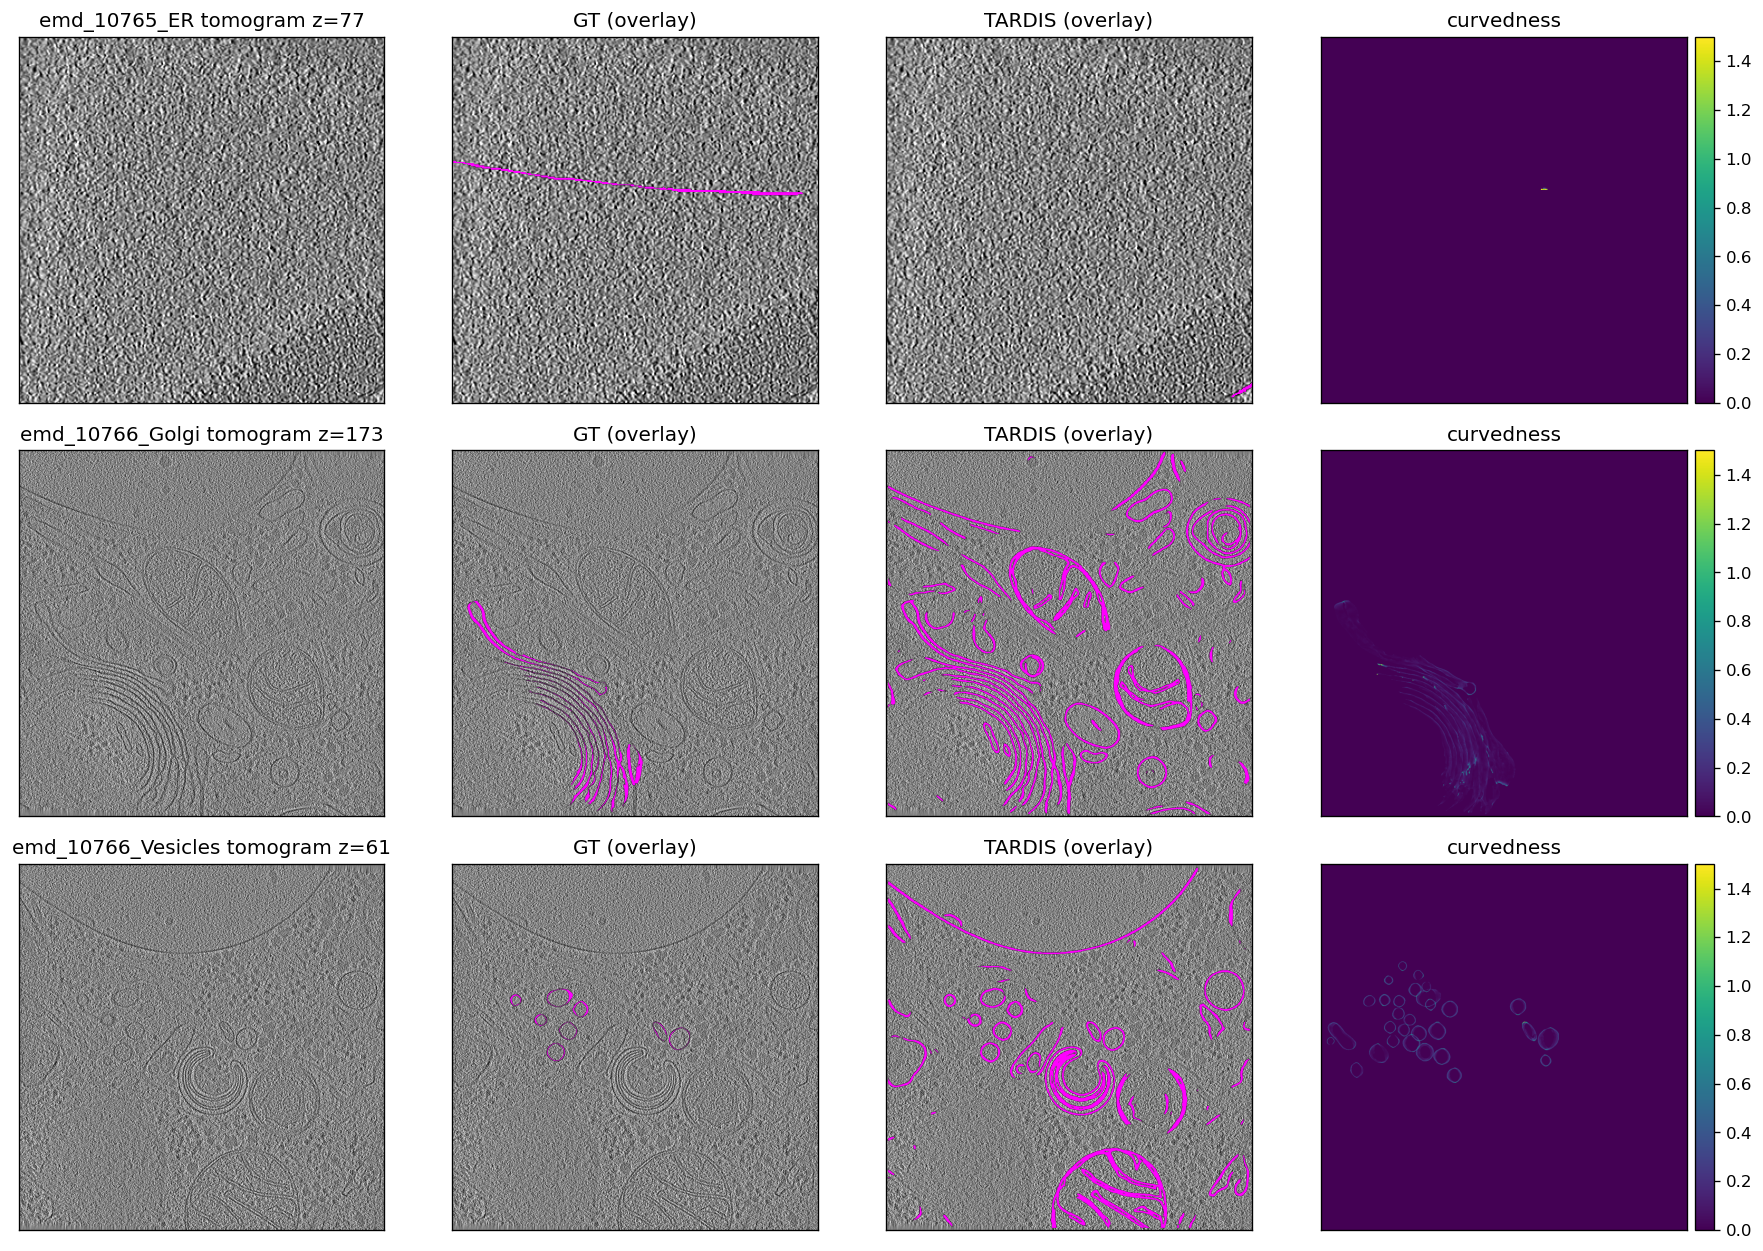

In [8]:
def _pick_z_with_content(gt):
    """Pick the Z slice with the most GT membrane voxels."""
    per_z = gt.astype(bool).sum(axis=(0, 1))
    return int(np.argmax(per_z)) if per_z.any() else gt.shape[2] // 2


def _norm(img, p_lo=1, p_hi=99):
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, [p_lo, p_hi])
    if hi <= lo:
        return np.zeros_like(img)
    return np.clip((img - lo) / (hi - lo), 0, 1)


def _binary_overlay(mask_slice):
    """Turn a slice (possibly multi-valued instance labels) into a masked bool
    image so imshow draws one solid color wherever the mask is non-zero."""
    b = mask_slice.T.astype(bool)
    return np.ma.masked_where(~b, b.astype(np.uint8))


names = list(datasets)
fig, axes = plt.subplots(len(names), 4, figsize=(15, 3.5 * len(names)), dpi=120)
if len(names) == 1:
    axes = axes[None, :]
for i, name in enumerate(names):
    d = datasets[name]
    z = _pick_z_with_content(d['gt'])
    tomo = d.get('tomogram')
    if tomo is not None:
        axes[i, 0].imshow(_norm(tomo[:, :, z]).T, cmap='gray')
    else:
        axes[i, 0].text(0.5, 0.5, 'no tomogram', ha='center', va='center',
                        transform=axes[i, 0].transAxes)
    axes[i, 0].set_title(f'{name} tomogram z={z}')

    base = _norm(tomo[:, :, z]).T if tomo is not None else np.zeros(d['gt'].shape[:2]).T
    axes[i, 1].imshow(base, cmap='gray')
    axes[i, 1].imshow(_binary_overlay(d['gt'][:, :, z-5:z+5].sum(axis=2)),
                      cmap='cool', vmin=0, vmax=1)
    axes[i, 1].set_title('GT (overlay)')

    axes[i, 2].imshow(base, cmap='gray')
    axes[i, 2].imshow(_binary_overlay(d['pred'][:, :, z]),
                      cmap='cool', vmin=0, vmax=1)
    axes[i, 2].set_title('TARDIS (overlay)')

    curv_slice = np.sum(d['curvedness'], axis=2).T
    im = axes[i, 3].imshow(curv_slice, cmap='viridis', vmin=0, vmax=1.5)
    axes[i, 3].set_title('curvedness')
    plt.colorbar(im, ax=axes[i, 3], fraction=0.046, pad=0.02)

    for ax in axes[i]:
        ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

In [9]:
def curvature_bins(gt_bin, curv_gt, n_bins=5, include_top_percentile=1.0):
    """Partition GT voxels into `n_bins` equal-count curvedness bins (low -> high),
    plus an optional tail mask at the top `include_top_percentile` %.

    Returns a list of (label, boolean-mask) pairs ordered from low to high
    curvedness so F1 can be plotted vs. curvature.
    """
    gt_bool = gt_bin.astype(bool)
    vals = curv_gt[gt_bool]
    vals = vals[vals > 0]
    if vals.size == 0:
        return []
    edges = np.quantile(vals, np.linspace(0, 1, n_bins + 1))
    bins = []
    lo_pct = np.linspace(0, 100, n_bins + 1)
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        in_bin = (curv_gt >= lo) & (curv_gt <= hi) if i == n_bins - 1 \
            else (curv_gt >= lo) & (curv_gt < hi)
        bins.append((f'q{i+1}_{int(lo_pct[i])}-{int(lo_pct[i+1])}%',
                     gt_bool & in_bin))
    if include_top_percentile:
        thr = np.quantile(vals, 1 - include_top_percentile / 100.0)
        bins.append((f'top{include_top_percentile:g}pct', gt_bool & (curv_gt >= thr)))
    return bins

In [10]:
rows = []
for name, d in datasets.items():
    gt, pred, curv_gt = d['gt'], d['pred'], d['curvedness_gt']
    regions = [('global', None), ('gt_only', gt.astype(bool))]
    regions.extend(curvature_bins(gt, curv_gt, n_bins=5, include_top_percentile=1.0))
    for region_name, mask in regions:
        m = seg_metrics(pred, gt, mask=mask)
        m.update({'dataset': name, 'region': region_name,
                  'n_voxels': int(mask.sum()) if mask is not None else int(gt.size)})
        rows.append(m)

results = pd.DataFrame(rows)[
    ['dataset', 'region', 'n_voxels',
     'Precision', 'Recall', 'F1', 'IoU', 'Dice', 'TP', 'FP', 'FN']
]
results

,dataset,region,n_voxels,Precision,Recall,F1,IoU,Dice,TP,FP,FN
0,emd_10765_ER,global,13232832,0.000000,0.000000,0.000000,0.000000,0.000000,0,5558,29961
1,emd_10765_ER,gt_only,29961,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,29961
2,emd_10765_ER,q1_0-20%,5785,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,5785
3,emd_10765_ER,q2_20-40%,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
4,emd_10765_ER,q3_40-60%,7425,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,7425
5,emd_10765_ER,q4_60-80%,6294,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,6294
6,emd_10765_ER,q5_80-100%,10457,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,10457
7,emd_10765_ER,top1pct,10457,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,10457
8,emd_10766_Golgi,global,215296000,0.020204,0.994917,0.039605,0.020202,0.039605,292227,14171298,1493
9,emd_10766_Golgi,gt_only,293720,1.000000,0.994917,0.997452,0.994917,0.997452,292227,0,1493


In [11]:
bin_order = ['global', 'gt_only',
             'q1_0-20%', 'q2_20-40%', 'q3_40-60%', 'q4_60-80%', 'q5_80-100%',
             'top1pct']
present = [r for r in bin_order if r in set(results.region)]
summary = (
    results
    .groupby('region')[['Precision', 'Recall', 'F1', 'IoU', 'Dice']]
    .mean()
    .reindex(present)
)
summary

,Precision,Recall,F1,IoU,Dice
region,,,,,
global,0.008369,0.627085,0.016451,0.008367,0.016451
gt_only,0.666667,0.627085,0.645732,0.627085,0.645732
q1_0-20%,0.666667,0.647525,0.656825,0.647525,0.656825
q2_20-40%,0.666667,0.643093,0.654465,0.643093,0.654465
q3_40-60%,0.666667,0.635615,0.650421,0.635615,0.650421
q4_60-80%,0.666667,0.623534,0.643681,0.623534,0.643681
q5_80-100%,0.666667,0.585660,0.621348,0.585660,0.621348
top1pct,0.666667,0.558944,0.602985,0.558944,0.602985


## Summary across datasets

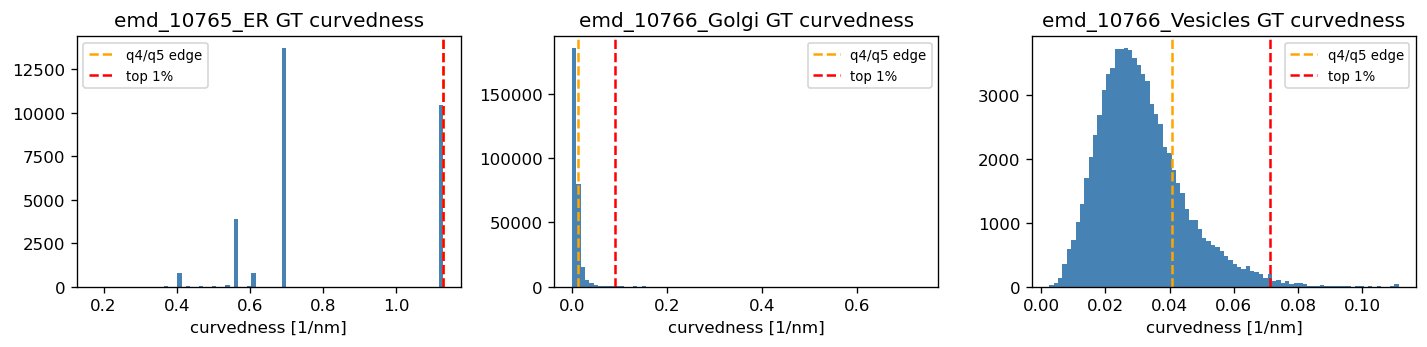

In [12]:
fig, axes = plt.subplots(1, len(datasets), figsize=(4 * len(datasets), 3), dpi=120)
if len(datasets) == 1:
    axes = [axes]
for ax, (name, d) in zip(axes, datasets.items()):
    gt_bool = d['gt'].astype(bool)
    c = d['curvedness_gt'][gt_bool]
    c = c[c > 0]
    ax.hist(c, bins=80, color='steelblue')
    if c.size:
        for pct, col, lbl in [(80, 'orange', 'q4/q5 edge'),
                              (99, 'red', 'top 1%')]:
            ax.axvline(np.percentile(c, pct), color=col, linestyle='--', label=lbl)
    ax.set_title(f'{name} GT curvedness')
    ax.set_xlabel('curvedness [1/nm]')
    ax.legend(fontsize=8)
fig.tight_layout()

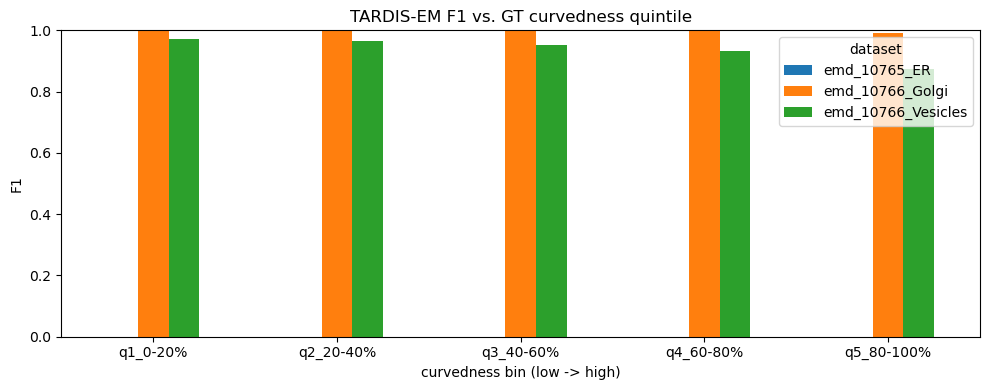

In [13]:
bin_cols = ['q1_0-20%', 'q2_20-40%', 'q3_40-60%', 'q4_60-80%', 'q5_80-100%']
pivot = (results.pivot_table(index='region', columns='dataset', values='F1')
         .reindex(bin_cols))
ax = pivot.plot(kind='bar', figsize=(10, 4), ylim=(0, 1))
ax.set_xlabel('curvedness bin (low -> high)')
ax.set_ylabel('F1')
ax.set_title('TARDIS-EM F1 vs. GT curvedness quintile')
plt.xticks(rotation=0)
plt.tight_layout()

In [14]:
results.pivot_table(index='region', columns='dataset', values='F1').reindex(bin_cols)

dataset,emd_10765_ER,emd_10766_Golgi,emd_10766_Vesicles
region,,,
q1_0-20%,0.0,0.999353,0.971124
q2_20-40%,0.0,0.999302,0.964093
q3_40-60%,0.0,0.998798,0.952465
q4_60-80%,0.0,0.998431,0.932613
q5_80-100%,0.0,0.991329,0.872714
